In [2]:
# Data handling
import pandas as pd
import numpy as np

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Explainability
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import pickle

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Cell 2: Load Preprocessed Data
X_train = np.load('../data/X_train.npy')
X_val = np.load('../data/X_val.npy')
X_test = np.load('../data/X_test.npy')

y_train = np.load('../data/y_train.npy')
y_val = np.load('../data/y_val.npy')
y_test = np.load('../data/y_test.npy')

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training:")
print(f"Benign (0): {(y_train == 0).sum()}")
print(f"Pathogenic (1): {(y_train == 1).sum()}")

Training set: (26153, 4)
Validation set: (5604, 4)
Test set: (5605, 4)

Class distribution in training:
Benign (0): 12743
Pathogenic (1): 13410


In [5]:
# Cell 3: Define Evaluation Function
def evaluate_model(y_true, y_pred, y_proba, set_name=""):
    """Calculate and display all metrics"""
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    avg_precision = average_precision_score(y_true, y_proba)
    
    print(f"\n{set_name} Set Metrics:")
    print(f"  Accuracy:           {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision:          {precision:.4f}")
    print(f"  Recall:             {recall:.4f}")
    print(f"  F1-Score:           {f1:.4f}")
    print(f"  ROC-AUC:            {roc_auc:.4f}")
    print(f"  Average Precision:  {avg_precision:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision
    }

print("✅ Evaluation function defined!")

✅ Evaluation function defined!


In [6]:
# Cell 4: Train Random Forest
print("=" * 60)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\n🌲 Training Random Forest...")
rf_model.fit(X_train, y_train)
print("✅ Random Forest training complete!")

# Make predictions
print("\n📊 Making predictions...")
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("✅ Predictions complete!")

TRAINING RANDOM FOREST CLASSIFIER

🌲 Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=18)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=18)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=18)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0

✅ Random Forest training complete!

📊 Making predictions...
✅ Predictions complete!


[Parallel(n_jobs=18)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=18)]: Done 100 out of 100 | elapsed:    0.0s finished


In [7]:
# Cell 5: Evaluate Random Forest
print("\n" + "=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

rf_train_metrics = evaluate_model(y_train, y_train_pred_rf, y_train_proba_rf, "Training")
rf_val_metrics = evaluate_model(y_val, y_val_pred_rf, y_val_proba_rf, "Validation")
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf, y_test_proba_rf, "Test")


RANDOM FOREST PERFORMANCE

Training Set Metrics:
  Accuracy:           0.9045 (90.45%)
  Precision:          0.9721
  Recall:             0.8378
  F1-Score:           0.9000
  ROC-AUC:            0.9799
  Average Precision:  0.9826

Validation Set Metrics:
  Accuracy:           0.8817 (88.17%)
  Precision:          0.9344
  Recall:             0.8274
  F1-Score:           0.8776
  ROC-AUC:            0.9320
  Average Precision:  0.9476

Test Set Metrics:
  Accuracy:           0.8771 (87.71%)
  Precision:          0.9403
  Recall:             0.8118
  F1-Score:           0.8713
  ROC-AUC:            0.9273
  Average Precision:  0.9477


In [8]:
# Cell 6: Train SVM
print("\n" + "=" * 60)
print("TRAINING SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42,
    verbose=True
)

print("\n🎯 Training SVM...")
svm_model.fit(X_train, y_train)
print("✅ SVM training complete!")

# Make predictions
print("\n📊 Making predictions...")
y_train_pred_svm = svm_model.predict(X_train)
y_val_pred_svm = svm_model.predict(X_val)
y_test_pred_svm = svm_model.predict(X_test)

y_train_proba_svm = svm_model.predict_proba(X_train)[:, 1]
y_val_proba_svm = svm_model.predict_proba(X_val)[:, 1]
y_test_proba_svm = svm_model.predict_proba(X_test)[:, 1]

print("✅ Predictions complete!")


TRAINING SUPPORT VECTOR MACHINE (SVM)

🎯 Training SVM...
[LibSVM]✅ SVM training complete!

📊 Making predictions...
✅ Predictions complete!


In [9]:
# Cell 7: Evaluate SVM
print("\n" + "=" * 60)
print("SVM PERFORMANCE")
print("=" * 60)

svm_train_metrics = evaluate_model(y_train, y_train_pred_svm, y_train_proba_svm, "Training")
svm_val_metrics = evaluate_model(y_val, y_val_pred_svm, y_val_proba_svm, "Validation")
svm_test_metrics = evaluate_model(y_test, y_test_pred_svm, y_test_proba_svm, "Test")


SVM PERFORMANCE

Training Set Metrics:
  Accuracy:           0.8662 (86.62%)
  Precision:          0.9403
  Recall:             0.7893
  F1-Score:           0.8582
  ROC-AUC:            0.8752
  Average Precision:  0.8917

Validation Set Metrics:
  Accuracy:           0.8688 (86.88%)
  Precision:          0.9349
  Recall:             0.7999
  F1-Score:           0.8621
  ROC-AUC:            0.8779
  Average Precision:  0.8864

Test Set Metrics:
  Accuracy:           0.8623 (86.23%)
  Precision:          0.9365
  Recall:             0.7846
  F1-Score:           0.8538
  ROC-AUC:            0.8660
  Average Precision:  0.8849


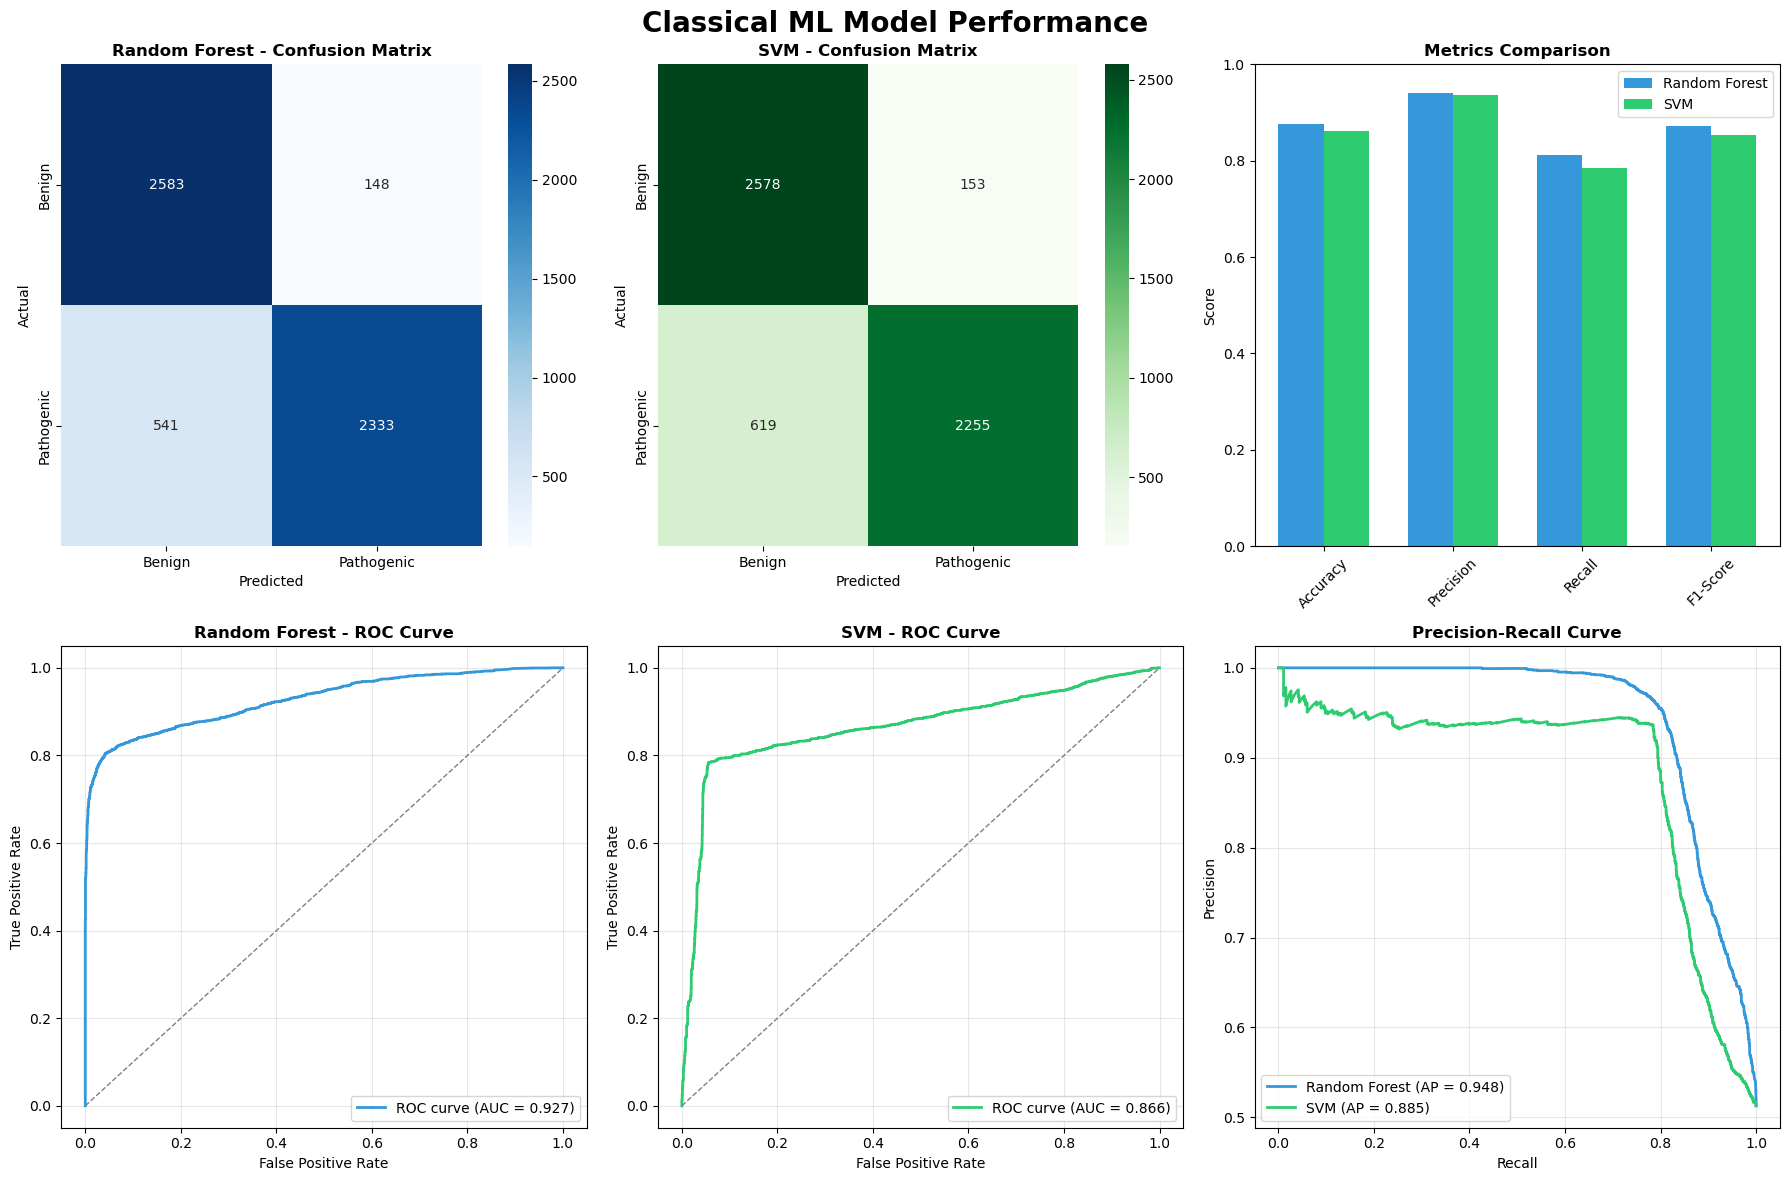

✅ Visualizations saved!


In [10]:
# Cell 8: Create Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Classical ML Model Performance', fontsize=20, fontweight='bold')

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Random Forest - Confusion Matrix', fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xticklabels(['Benign', 'Pathogenic'])
axes[0, 0].set_yticklabels(['Benign', 'Pathogenic'])

# Confusion Matrix - SVM
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1])
axes[0, 1].set_title('SVM - Confusion Matrix', fontweight='bold')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_xticklabels(['Benign', 'Pathogenic'])
axes[0, 1].set_yticklabels(['Benign', 'Pathogenic'])

# Metrics Comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_values = [rf_test_metrics['accuracy'], rf_test_metrics['precision'], 
             rf_test_metrics['recall'], rf_test_metrics['f1']]
svm_values = [svm_test_metrics['accuracy'], svm_test_metrics['precision'], 
              svm_test_metrics['recall'], svm_test_metrics['f1']]

x = np.arange(len(metrics_names))
width = 0.35

axes[0, 2].bar(x - width/2, rf_values, width, label='Random Forest', color='#3498db')
axes[0, 2].bar(x + width/2, svm_values, width, label='SVM', color='#2ecc71')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_title('Metrics Comparison', fontweight='bold')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(metrics_names, rotation=45)
axes[0, 2].legend()
axes[0, 2].set_ylim([0, 1])

# ROC Curve - Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
axes[1, 0].plot(fpr_rf, tpr_rf, color='#3498db', lw=2, 
                label=f'ROC curve (AUC = {rf_test_metrics["roc_auc"]:.3f})')
axes[1, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Random Forest - ROC Curve', fontweight='bold')
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(alpha=0.3)

# ROC Curve - SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_test_proba_svm)
axes[1, 1].plot(fpr_svm, tpr_svm, color='#2ecc71', lw=2, 
                label=f'ROC curve (AUC = {svm_test_metrics["roc_auc"]:.3f})')
axes[1, 1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('SVM - ROC Curve', fontweight='bold')
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(alpha=0.3)

# Precision-Recall Curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_test_proba_rf)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_test_proba_svm)

axes[1, 2].plot(recall_rf, precision_rf, color='#3498db', lw=2, 
                label=f'Random Forest (AP = {rf_test_metrics["avg_precision"]:.3f})')
axes[1, 2].plot(recall_svm, precision_svm, color='#2ecc71', lw=2, 
                label=f'SVM (AP = {svm_test_metrics["avg_precision"]:.3f})')
axes[1, 2].set_xlabel('Recall')
axes[1, 2].set_ylabel('Precision')
axes[1, 2].set_title('Precision-Recall Curve', fontweight='bold')
axes[1, 2].legend(loc="lower left")
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/classical_ml_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved!")


SHAP EXPLAINABILITY ANALYSIS

🔍 Calculating SHAP values for 500 test samples...
✅ SHAP values calculated!


<Figure size 1200x600 with 0 Axes>

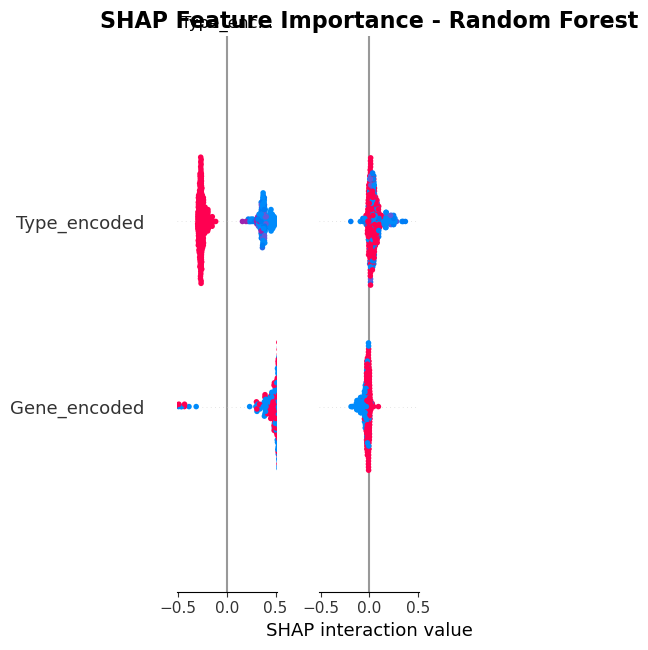

✅ SHAP visualization saved!


In [14]:
# Cell 9: SHAP Explainability
print("\n" + "=" * 60)
print("SHAP EXPLAINABILITY ANALYSIS")
print("=" * 60)

sample_size = 500
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
X_test_sample = X_test[sample_indices]

print(f"\n🔍 Calculating SHAP values for {sample_size} test samples...")

# Create SHAP explainer
explainer_rf = shap.TreeExplainer(rf_model)

# Calculate SHAP values using new API
shap_values = explainer_rf(X_test_sample)

print("✅ SHAP values calculated!")

# Feature names
feature_names = ['Gene_encoded', 'Type_encoded', 'Start', 'Mutation_length']

# SHAP Summary Plot - Pass features as DataFrame with column names
import pandas as pd
X_test_sample_df = pd.DataFrame(X_test_sample, columns=feature_names)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_sample_df, show=False)
plt.title('SHAP Feature Importance - Random Forest', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ SHAP visualization saved!")

In [15]:
# Cell 10: Save Models
print("\n" + "=" * 60)
print("SAVING TRAINED MODELS")
print("=" * 60)

with open('../models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✅ Random Forest saved: models/random_forest_model.pkl")

with open('../models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("✅ SVM saved: models/svm_model.pkl")

metrics_summary = {
    'random_forest': {
        'train': rf_train_metrics,
        'val': rf_val_metrics,
        'test': rf_test_metrics
    },
    'svm': {
        'train': svm_train_metrics,
        'val': svm_val_metrics,
        'test': svm_test_metrics
    }
}

with open('../models/metrics_summary.pkl', 'wb') as f:
    pickle.dump(metrics_summary, f)
print("✅ Metrics saved: models/metrics_summary.pkl")

print("\n🎉 All models and metrics saved successfully!")


SAVING TRAINED MODELS
✅ Random Forest saved: models/random_forest_model.pkl
✅ SVM saved: models/svm_model.pkl
✅ Metrics saved: models/metrics_summary.pkl

🎉 All models and metrics saved successfully!


In [16]:
# Cell 11: Summary Report
print("\n" + "=" * 80)
print("WEEK 3 SUMMARY REPORT")
print("=" * 80)

print("\n📊 FINAL TEST SET PERFORMANCE:")
print("-" * 80)

print("\n🌲 Random Forest:")
print(f"  Accuracy:  {rf_test_metrics['accuracy']:.4f} ({rf_test_metrics['accuracy']*100:.2f}%)")
print(f"  Precision: {rf_test_metrics['precision']:.4f}")
print(f"  Recall:    {rf_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {rf_test_metrics['f1']:.4f}")
print(f"  ROC-AUC:   {rf_test_metrics['roc_auc']:.4f}")

print("\n🎯 SVM:")
print(f"  Accuracy:  {svm_test_metrics['accuracy']:.4f} ({svm_test_metrics['accuracy']*100:.2f}%)")
print(f"  Precision: {svm_test_metrics['precision']:.4f}")
print(f"  Recall:    {svm_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {svm_test_metrics['f1']:.4f}")
print(f"  ROC-AUC:   {svm_test_metrics['roc_auc']:.4f}")

if rf_test_metrics['f1'] > svm_test_metrics['f1']:
    print("\n🏆 BEST MODEL: Random Forest")
else:
    print("\n🏆 BEST MODEL: SVM")

print("\n" + "=" * 80)
print("✅ WEEK 3 COMPLETE!")
print("=" * 80)


WEEK 3 SUMMARY REPORT

📊 FINAL TEST SET PERFORMANCE:
--------------------------------------------------------------------------------

🌲 Random Forest:
  Accuracy:  0.8771 (87.71%)
  Precision: 0.9403
  Recall:    0.8118
  F1-Score:  0.8713
  ROC-AUC:   0.9273

🎯 SVM:
  Accuracy:  0.8623 (86.23%)
  Precision: 0.9365
  Recall:    0.7846
  F1-Score:  0.8538
  ROC-AUC:   0.8660

🏆 BEST MODEL: Random Forest

✅ WEEK 3 COMPLETE!


In [17]:
import shap
import numpy as np

print(f"SHAP version: {shap.__version__}")
print(f"NumPy version: {np.__version__}")

# Quick test
explainer = shap.TreeExplainer(rf_model)
print("✅ SHAP TreeExplainer works!")

SHAP version: 0.45.1
NumPy version: 1.26.4
✅ SHAP TreeExplainer works!
